# Testing notebook

This Notebook can be used as a demo of the package and some of the main functions in it.


Johan Rosgaard, 04/12/2026

### Load imports

In [118]:
# Main module
%reset -f

# autoreload imports
%load_ext autoreload
%autoreload 2

from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'lightgray'
plt.rcParams['axes.facecolor'] = 'white'


from neurons_model.simulation.config import NetworkConfig
from neurons_model.simulation.network import Network
from neurons_model.simulation.simulation import run_simulation
from neurons_model.simulation.scaling import scale_network_config

from neurons_model.readouts.sim_metrics import compute_metrics
from neurons_model.readouts.plot_metrics import plot_spike_raster
from neurons_model.readouts.pop_plot import plot_weight_heatmap, plot_connectivity_heatmap, plot_population_weight_summary
from neurons_model.readouts.sweep_plot import normalize, sweep_plot_general, sweep_plot_norm_summary
from neurons_model.readouts.calvo_analysis import calvo_pca, calvo_pca_plot

from neurons_model.functionals import functional_J


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [119]:

# --- Set diagnostic mode --- Change to True to enable extended diagnostic/verification output and characterization
diagnostic_mode = False

if diagnostic_mode:
    print("Running in diagnostic mode: Print extended output and characterization.")


# --- Set saving mode --- Change to True to enable saving of sweep results to CSV
saving_mode = False

if saving_mode:
    print("Running in saving mode: Save sweep results to CSV.")

# --- Set extended output metrics mode --- Change to True to enable extended output and characterization
extnd_mode = True

if extnd_mode:
    print("Running in extended output mode: Compute and print additional metrics.")


Running in extended output mode: Compute and print additional metrics.


## Opening npz sweep files

#### Sweep 0001

This sweep was an initial test. 

In [ ]:
# Load sweep data
data_path = '/Users/johanrosgaard/Documents/BNQ/neurons_model/tests/sweep_results/sweep_test_0001/sweep_output_data_20260410_211822.npz'
sweep_data = np.load(data_path, allow_pickle=True)

# --- Diagnostic output ---
#diagnostic_mode = False
#diagnostic_mode = True

if diagnostic_mode:
    print("Sweep data keys:", sweep_data.files)
    print("\nSweep data shapes:")
    for key in sweep_data.files:
        print(f"{key} dtype: {sweep_data[key].dtype}, shape: {sweep_data[key].shape}")

sweep_0001_df = pd.DataFrame({k: sweep_data[k] for k in sweep_data.files})

if diagnostic_mode:
    print(sweep_0001_df.head())

# Save to CSV
if saving_mode:
    sweep_0001_df.to_csv("Sweep_csv_files/_sweep_0001_file_output_data_20260410_211822.csv", index=False)

# Print top 10 best and worst performing parameter sets based on functional value
sweep_0001_df.sort_values("functional_val", ascending=False).head(10)
sweep_0001_df.sort_values("functional_val", ascending=True).head(10)

sweep_0001_df.groupby("pathway")[["functional_val", "total_spikes", "field_proxy_max"]].mean()

#print("Unique pathway values:", sweep_0001_df["pathway"].unique())
#print("Sweep weight values:", sweep_0001_df["swept_weight"].unique())


,functional_val,total_spikes,field_proxy_max
pathway,,,
Ex->Ex,-13.152999,0.0,0.0
Ex->In_adapt,-13.153752,0.0,0.0
Ex->In_fast,-13.153746,0.0,0.0
In_adapt->Ex,-13.153752,0.0,0.0
In_adapt->In_adapt,-13.153756,0.0,0.0
In_adapt->In_fast,-13.153756,0.0,0.0
In_fast->Ex,-13.153745,0.0,0.0
In_fast->In_adapt,-13.153755,0.0,0.0
In_fast->In_fast,-13.153756,0.0,0.0


In [121]:
# Control ploting of sweep results: Change to True to plotting
plot = False

if plot:
    for pathway, subdf in sweep_0001_df.groupby("pathway"):
        subdf = subdf.sort_values("multiplier")
        plt.figure()
        plt.plot(subdf["multiplier"], subdf["functional_val"], marker="o")
        plt.title(pathway)
        plt.xlabel("Multiplier")
        plt.ylabel("Functional value")
        plt.show()

#### Sweep 0002

This sweep was too narrow. It was used to experiment with plotting metrics.

In [ ]:
# Load sweep data
data_path = '/Users/johanrosgaard/Documents/BNQ/neurons_model/tests/sweep_results/sweep_test_0002/sweep_output_data_20260411_082648.npz'
sweep_data = np.load(data_path, allow_pickle=True)

# --- Diagnostic output ---
#diagnostic_mode = True

if diagnostic_mode:
    print("Sweep data keys:", sweep_data.files)
    print("\nSweep data shapes:")
    for key in sweep_data.files:
        print(f"{key} dtype: {sweep_data[key].dtype}, shape: {sweep_data[key].shape}")


sweep_0002_df = pd.DataFrame({k: sweep_data[k] for k in sweep_data.files})

if diagnostic_mode:
    print(sweep_0002_df.head())

# Save to CSV
if saving_mode:
    sweep_0002_df.to_csv("Sweep_csv_files/_sweep_0002_file_output_data_20260411_082648.csv", index=False)

# Print top 10 best and worst performing parameter sets based on functional value
sweep_0002_df.sort_values("functional_val", ascending=False).head(10)
sweep_0002_df.sort_values("functional_val", ascending=True).head(10)

sweep_0002_df.groupby("pathway")[["functional_val", "total_spikes", "field_proxy_max"]].mean()

# Base pathway weights
base_weights = {"Ex->Ex": 0.012,
                "In_fast->Ex": 0.04,
                "In_adapt->Ex": 0.04}

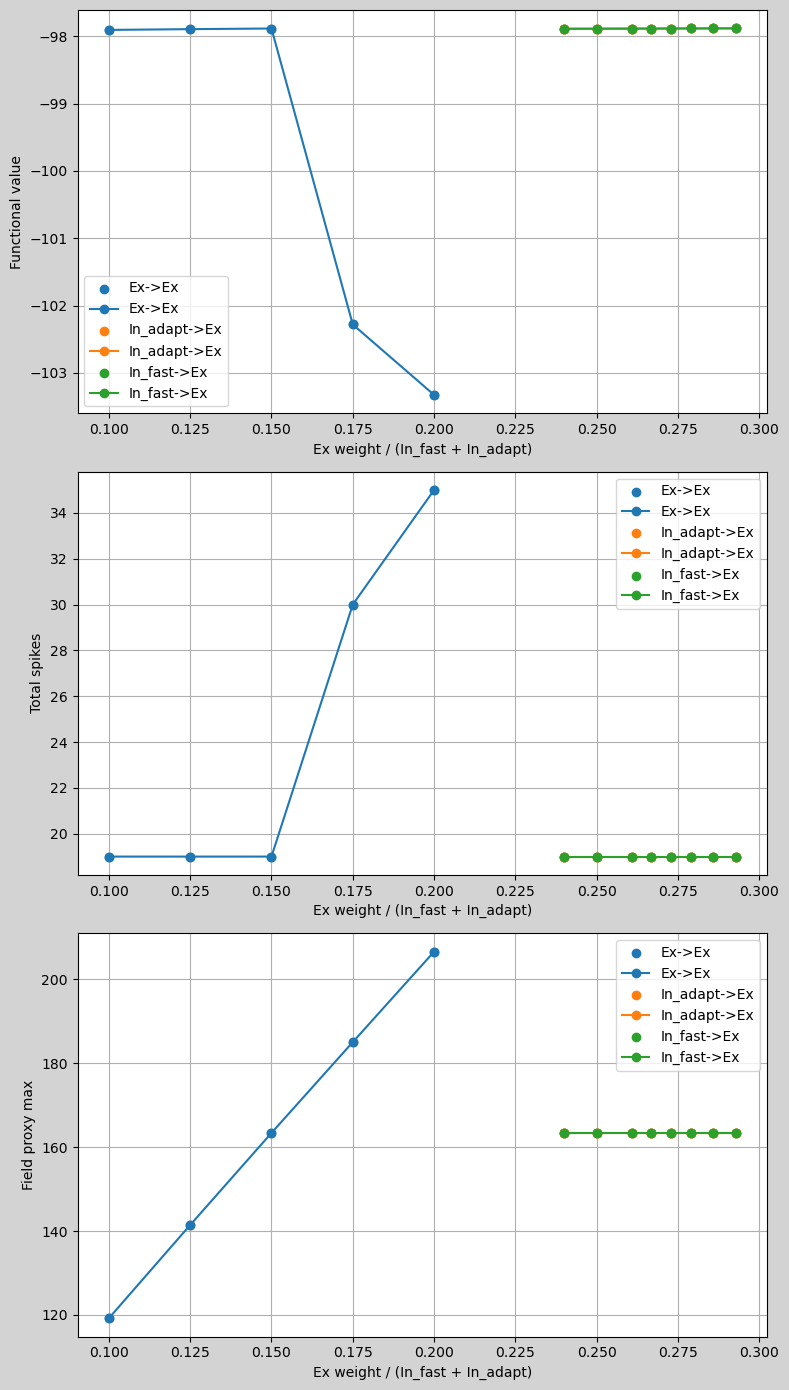

In [123]:
# Function to compute Ex/In ratio for each pathway
# Take this Ex/In ratio with a grain of salt, as it is a very rough representation and does not account for many factors such as nonlinearities, network dynamics, etc.
def compute_ex_in_ratio(subdf, pathway, base_weights):
    if pathway == "Ex->Ex":
        return subdf["swept_weight"] / (
            base_weights["In_fast->Ex"] + base_weights["In_adapt->Ex"]
        )
    elif pathway == "In_fast->Ex":
        return base_weights["Ex->Ex"] / (
            subdf["swept_weight"] + base_weights["In_adapt->Ex"]
        )
    elif pathway == "In_adapt->Ex":
        return base_weights["Ex->Ex"] / (
            base_weights["In_fast->Ex"] + subdf["swept_weight"]
        )
    else:
        raise ValueError(f"Unknown pathway: {pathway}")


plt.figure(figsize=(8, 14))

for pathway, subdf in sweep_0002_df.groupby("pathway"):
    ex_in_ratio = compute_ex_in_ratio(subdf, pathway, base_weights)
    order = np.argsort(ex_in_ratio.values)

    plt.subplot(3, 1, 1)
    plt.scatter(ex_in_ratio, subdf["functional_val"], label=pathway)
    plt.plot(ex_in_ratio.values[order], subdf["functional_val"].values[order], marker="o", label=pathway)


    plt.subplot(3, 1, 2)
    plt.scatter(ex_in_ratio, subdf["total_spikes"], label=pathway)
    plt.plot(ex_in_ratio.values[order], subdf["total_spikes"].values[order], marker="o", label=pathway)


    plt.subplot(3, 1, 3)
    plt.scatter(ex_in_ratio, subdf["field_proxy_max"], label=pathway)
    plt.plot(ex_in_ratio.values[order], subdf["field_proxy_max"].values[order], marker="o", label=pathway)

plt.subplot(3, 1, 1)
plt.xlabel("Ex weight / (In_fast + In_adapt)")
plt.ylabel("Functional value")
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.xlabel("Ex weight / (In_fast + In_adapt)")
plt.ylabel("Total spikes")
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
plt.xlabel("Ex weight / (In_fast + In_adapt)")
plt.ylabel("Field proxy max")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [124]:
plot = False

if plot:
    for pathway, subdf in sweep_0002_df.groupby("pathway"):
        subdf = subdf.sort_values("swept_weight")

        plt.figure(figsize=(6, 4))
        plt.plot(subdf["swept_weight"], subdf["Ex_mean_firing_rate_hz"], marker="o")
        plt.title(f"{pathway}: firing-rate regime curve")
        plt.xlabel("Swept weight")
        plt.ylabel("Ex mean firing rate (Hz)")
        plt.grid()
        plt.tight_layout()
        plt.show()

#### Sweep 0003

Sweep through Ex->Ex weight values from 0.000 to 0.025

In [ ]:
# Load sweep data
data_path = '/Users/johanrosgaard/Documents/BNQ/neurons_model/tests/sweep_results/sweep_test_0003/sweep_output_data_20260411_091109.npz'
sweep_data = np.load(data_path, allow_pickle=True)

# --- Diagnostic output ---
diagnostic_mode = False

if diagnostic_mode:
    print("Sweep data keys:", sweep_data.files)
    print("\nSweep data shapes:")
    for key in sweep_data.files:
        print(f"{key} dtype: {sweep_data[key].dtype}, shape: {sweep_data[key].shape}")

sweep_0003_df = pd.DataFrame({k: sweep_data[k] for k in sweep_data.files})

if diagnostic_mode:
    print(sweep_0003_df.head())

# Save to CSV
if saving_mode:
    sweep_0003_df.to_csv("Sweep_csv_files/_sweep_0003_file_output_data_20260411_091109.csv", index=False)

# Print top 10 best and worst performing parameter sets based on functional value
sweep_0003_df.sort_values("functional_val", ascending=False).head(10)
sweep_0003_df.sort_values("functional_val", ascending=True).head(10)

sweep_0003_df.groupby("pathway")[["functional_val", "total_spikes", "field_proxy_max"]].mean()

# Base pathway weights
base_weights = {"Ex->Ex": 0.012,
                "In_fast->Ex": 0.04,
                "In_adapt->Ex": 0.04}

# Make subdf for Ex->Ex pathway and plot firing rate and functional value vs swept weight
subdf = sweep_0003_df[sweep_0003_df["pathway"] == "Ex->Ex"].sort_values("swept_weight").copy()


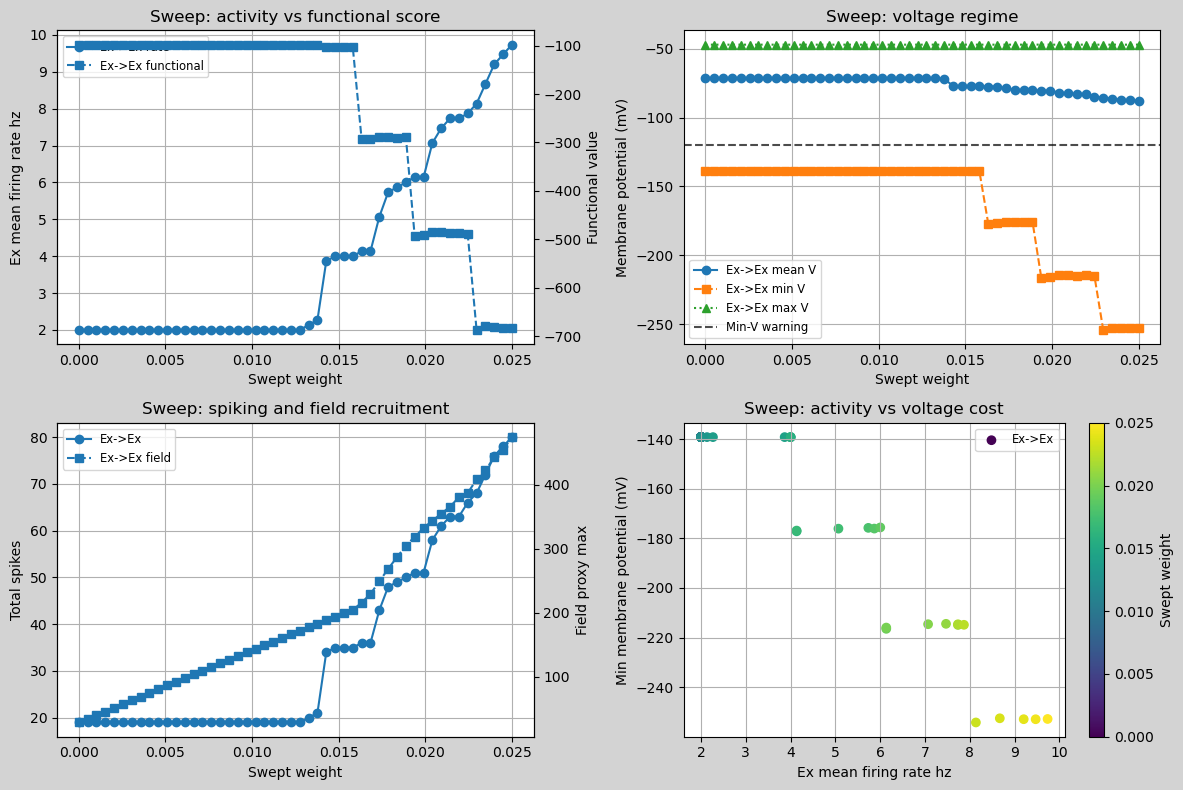

In [126]:
sweep_plot_general(subdf)

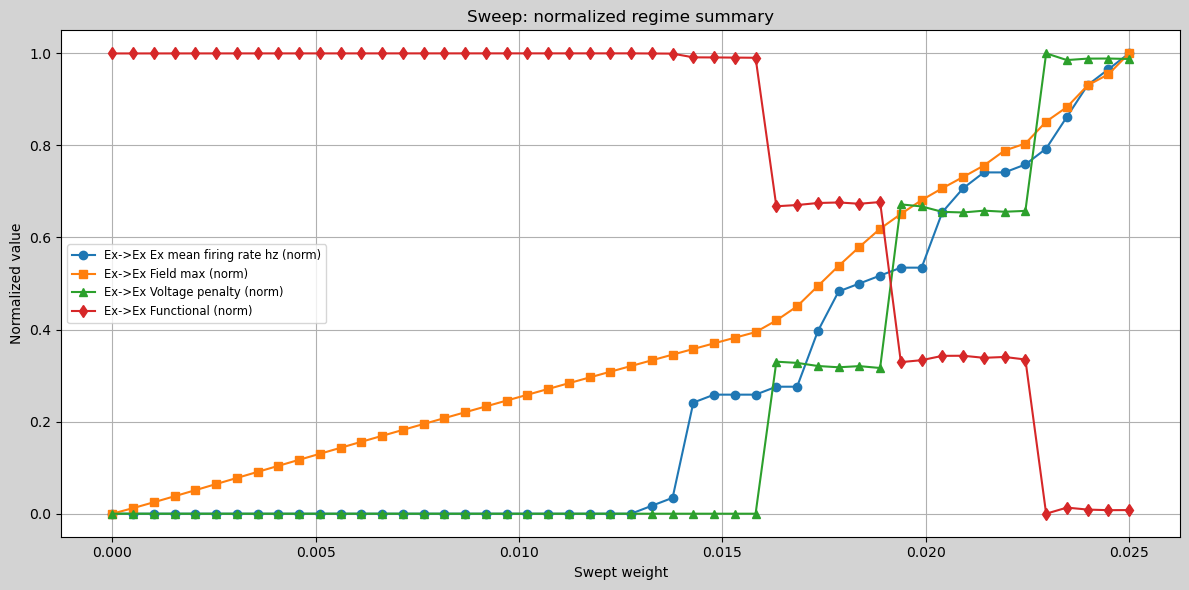

In [127]:
sweep_plot_norm_summary(subdf)

In [145]:
subdf = subdf.sort_values("swept_weight").copy()

# Compute normalized metrics for candidate window identification
subdf["Ex_rate_norm"] = normalize(subdf["Ex_mean_firing_rate_hz"])
subdf["field_norm"] = normalize(subdf["field_proxy_max"])
subdf["minV_instability_norm"] = 1 - normalize(subdf["min_membrane_potential_mv"])
subdf["functional_norm"] = normalize(subdf["functional_val"])

# Compute gradients of key metrics with respect to swept weight to identify regions of rapid change
subdf["d_rate"] = np.gradient(subdf["Ex_mean_firing_rate_hz"], subdf["swept_weight"])
subdf["d_field"] = np.gradient(subdf["field_proxy_max"], subdf["swept_weight"])
subdf["d_func"] = np.gradient(subdf["functional_val"], subdf["swept_weight"])

# Print normalized metrics for debugging
#print(subdf[["swept_weight", "Ex_rate_norm", "field_norm", "minV_instability_norm", "functional_norm"]].head())

print("Length of subdf:", len(subdf))

# Define candidate window based on normalized metrics
stable_window = subdf[
    (subdf["Ex_rate_norm"] > 0.2) &
    (subdf["field_norm"] > 0.0) &
    (subdf["minV_instability_norm"] < 0.4) &
    (subdf["functional_norm"] > 0.8)
]

print(len(stable_window), "stable candidates identified.")

# Define more stringent criteria for acceptable active candidates
transition_window = subdf[
    (subdf["Ex_rate_norm"] > 0.4) &
    (subdf["Ex_rate_norm"] < 0.6) &
    
    (subdf["field_norm"] > 0.0) &
    (subdf["field_norm"] < 0.8) &

    (subdf["minV_instability_norm"] > 0.3) &
    (subdf["minV_instability_norm"] < 0.8) &

    (subdf["functional_norm"] > 0.4) &
    (subdf["functional_norm"] < 0.8)
]

print(len(transition_window), "transition candidates identified.")

unstable_window = subdf[
    (subdf["Ex_rate_norm"] > 0.8) &
    (subdf["field_norm"] > 0.8) &
    (subdf["minV_instability_norm"] > 0.8) &
    (subdf["functional_norm"] < 0.2)
]

print(len(unstable_window), "unstable candidates identified.")

Length of subdf: 50
4 stable candidates identified.
3 transition candidates identified.
4 unstable candidates identified.


In [147]:
# Control printing of candidates: Change to True to enable printing
# Output might be long, so default is False
print_candidates = True

if print_candidates:
    print("Stable window:")
    print(stable_window[["swept_weight", "functional_norm"]].sort_values("functional_norm", ascending=False).head(1))

    print("\n\nTransition window:")
    print(transition_window[["swept_weight", "functional_norm"]].sort_values("functional_norm", ascending=False).head(1))

    print("\n\nUnstable window:")
    print(unstable_window[["swept_weight", "functional_norm"]].sort_values("functional_norm", ascending=False).head(1))



Stable window:
    swept_weight  functional_norm
28      0.014286         0.991294


Transition window:
    swept_weight  functional_norm
37      0.018878         0.676963


Unstable window:
    swept_weight  functional_norm
46      0.023469          0.01326


#### Sweep 0004

Sweep through In_fast->Ex and In_adapt->Ex weight values from 0.000 to 0.014

In [ ]:
# Load sweep data
data_path = '/Users/johanrosgaard/Documents/BNQ/neurons_model/tests/sweep_results/sweep_test_0004/sweep_output_data_20260412_151252.npz'
sweep_data = np.load(data_path, allow_pickle=True)

# --- Diagnostic output ---
#diagnostic_mode = True

if diagnostic_mode:
    print("Sweep data keys:", sweep_data.files)
    print("\nSweep data shapes:")
    for key in sweep_data.files:
        print(f"{key} dtype: {sweep_data[key].dtype}, shape: {sweep_data[key].shape}")

sweep_0004_df = pd.DataFrame({k: sweep_data[k] for k in sweep_data.files})

if diagnostic_mode:
    print(sweep_0004_df.head())

# Save to CSV
if saving_mode:
    sweep_0004_df.to_csv("Sweep_csv_files/_sweep_0004_file_output_data_20260412_151252.csv", index=False)

# Print top 10 best and worst performing parameter sets based on functional value
sweep_0004_df.sort_values("functional_val", ascending=False).head(10)
sweep_0004_df.sort_values("functional_val", ascending=True).head(10)

sweep_0004_df.groupby("pathway")[["functional_val", "total_spikes", "field_proxy_max"]].mean()

# Base pathway weights
base_weights = {"Ex->Ex": 0.014796,
                "In_fast->Ex": 0.004,
                "In_adapt->Ex": 0.004}

# Make subdf for Ex->Ex pathway and plot firing rate and functional value vs swept weight
subdf_0004_fast = sweep_0004_df[sweep_0004_df["pathway"] == "In_fast->Ex"].sort_values("swept_weight").copy()
subdf_0004_adapt = sweep_0004_df[sweep_0004_df["pathway"] == "In_adapt->Ex"].sort_values("swept_weight").copy()


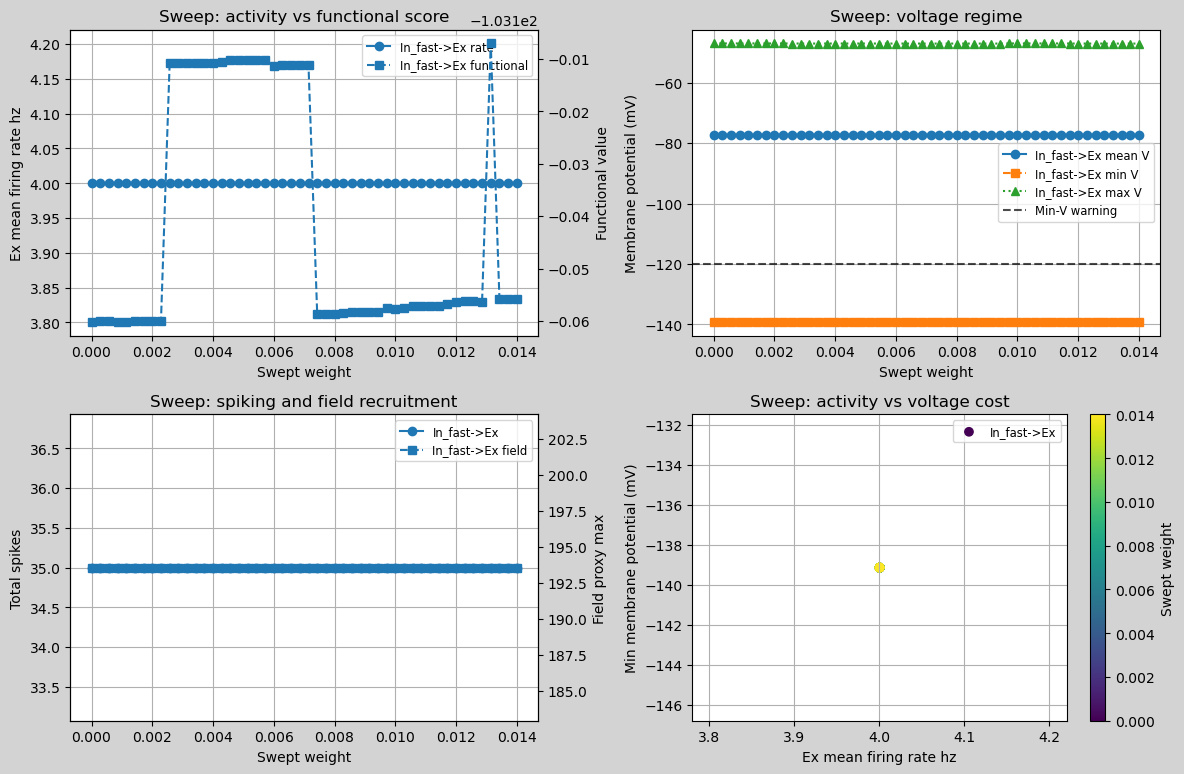

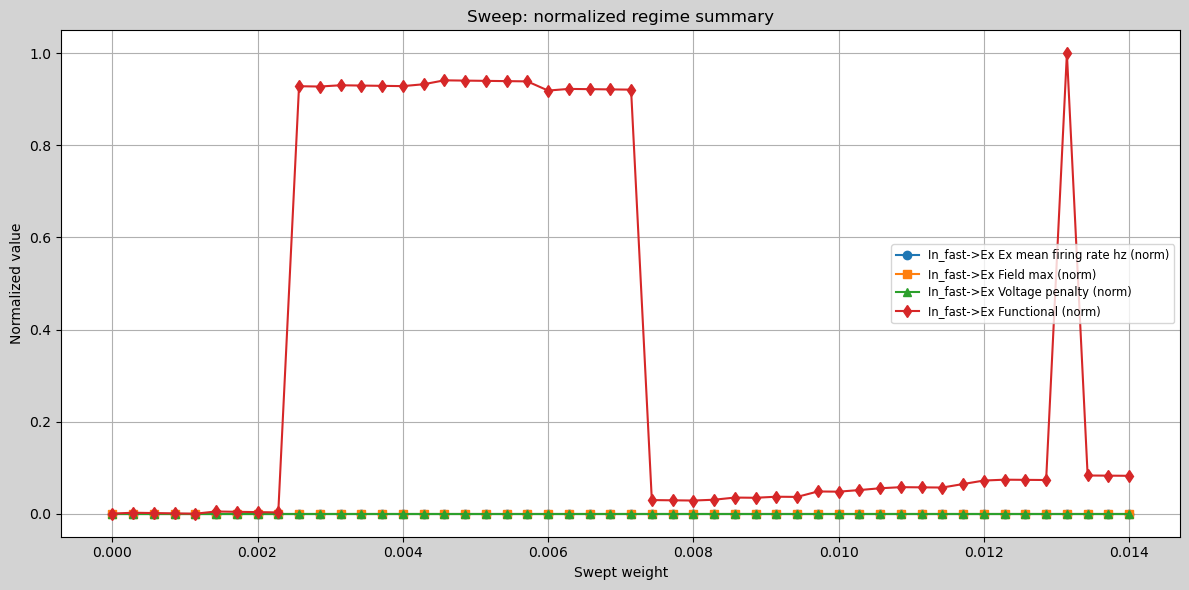

In [149]:
sweep_plot_general(subdf_0004_fast)

sweep_plot_norm_summary(subdf_0004_fast)

In [153]:
subdf = subdf_0004_fast.sort_values("swept_weight").copy()

baseline = subdf.iloc[0]

subdf["delta_rate"] = np.abs(subdf["Ex_mean_firing_rate_hz"] - baseline["Ex_mean_firing_rate_hz"])
subdf["delta_field"] = np.abs(subdf["field_proxy_max"] - baseline["field_proxy_max"])
subdf["delta_func"] = np.abs(subdf["functional_val"] - baseline["functional_val"])
subdf["delta_minV"] = np.abs(subdf["min_membrane_potential_mv"] - baseline["min_membrane_potential_mv"])

stable_window = subdf[
    (subdf["delta_rate"] < 0.25) &
    (subdf["delta_field"] < 5.0) &
    (subdf["delta_func"] < 1.0) &
    (subdf["delta_minV"] < 2.0)
]

transition_window = subdf[
    (
        (subdf["delta_rate"] >= 0.25) |
        (subdf["delta_field"] >= 5.0) |
        (subdf["delta_func"] >= 1.0) |
        (subdf["delta_minV"] >= 2.0)
    ) &
    (
        (subdf["delta_rate"] < 1.0) &
        (subdf["delta_field"] < 25.0) &
        (subdf["delta_func"] < 5.0) &
        (subdf["delta_minV"] < 10.0)
    )
]

unstable_window = subdf[
    (subdf["delta_rate"] >= 1.0) |
    (subdf["delta_field"] >= 25.0) |
    (subdf["delta_func"] >= 5.0) |
    (subdf["delta_minV"] >= 10.0) |
    (~subdf["v_finite"]) |
    (~subdf["field_finite"])
]

# Control printing of candidates: Change to True to enable printing
# Output might be long, so default is False
print_candidates = True

if print_candidates:
    print("Stable window:")
    print(stable_window[["swept_weight", "delta_func"]].sort_values("delta_func", ascending=False).head(1))

    print("\n\nTransition window:")
    print(transition_window[["swept_weight", "delta_func"]].sort_values("delta_func", ascending=False).head(1))

    print("\n\nUnstable window:")
    print(unstable_window[["swept_weight", "delta_func"]].sort_values("delta_func", ascending=False).head(1))

Stable window:
    swept_weight  delta_func
46      0.013143      0.0531


Transition window:
Empty DataFrame
Columns: [swept_weight, delta_func]
Index: []


Unstable window:
Empty DataFrame
Columns: [swept_weight, delta_func]
Index: []


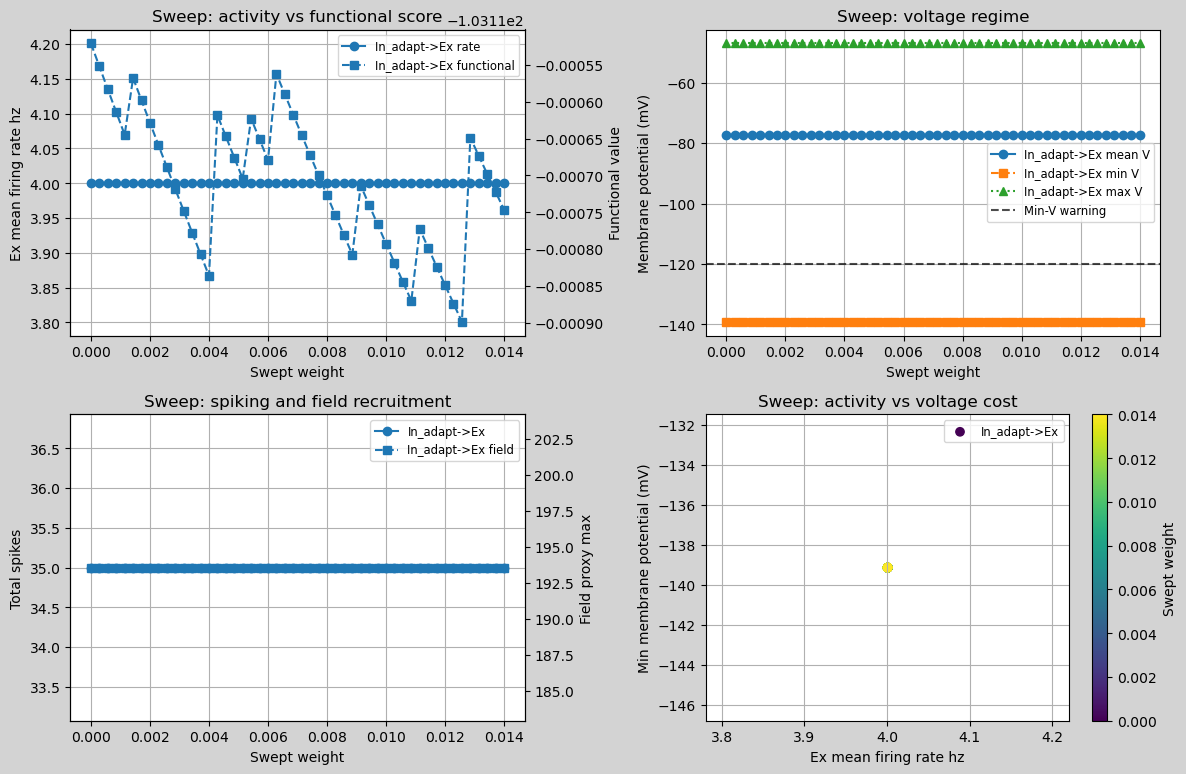

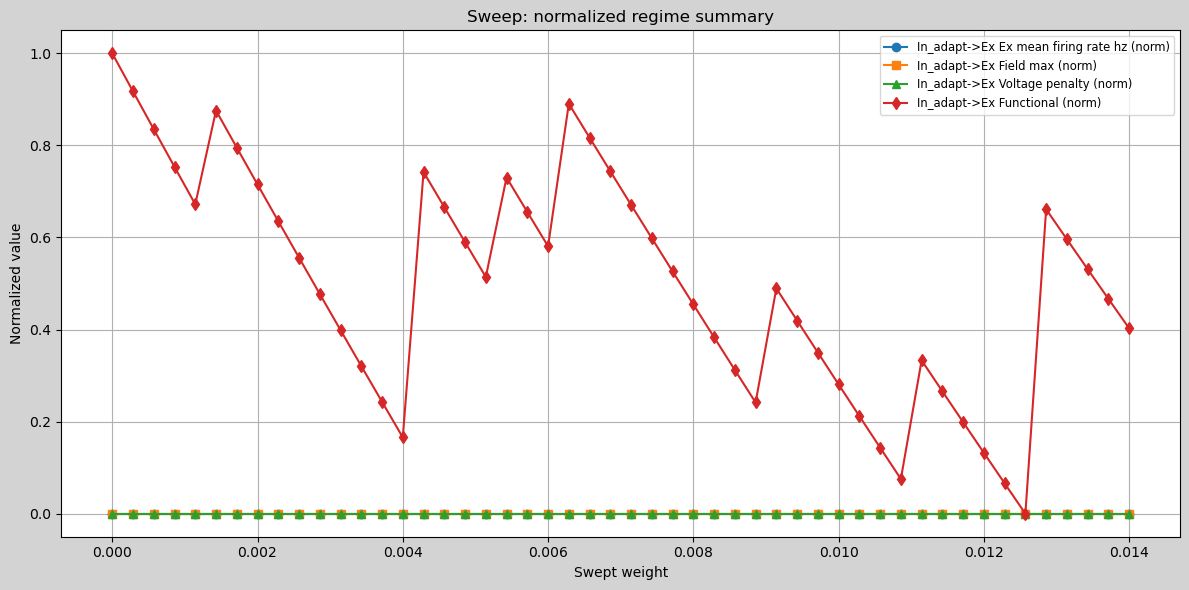

In [67]:
sweep_plot_general(subdf_0004_adapt)

sweep_plot_norm_summary(subdf_0004_adapt)

In [154]:
subdf = subdf_0004_adapt.sort_values("swept_weight").copy()

baseline = subdf.iloc[0]

subdf["delta_rate"] = np.abs(subdf["Ex_mean_firing_rate_hz"] - baseline["Ex_mean_firing_rate_hz"])
subdf["delta_field"] = np.abs(subdf["field_proxy_max"] - baseline["field_proxy_max"])
subdf["delta_func"] = np.abs(subdf["functional_val"] - baseline["functional_val"])
subdf["delta_minV"] = np.abs(subdf["min_membrane_potential_mv"] - baseline["min_membrane_potential_mv"])

stable_window = subdf[
    (subdf["delta_rate"] < 0.25) &
    (subdf["delta_field"] < 5.0) &
    (subdf["delta_func"] < 1.0) &
    (subdf["delta_minV"] < 2.0)
]

transition_window = subdf[
    (
        (subdf["delta_rate"] >= 0.25) |
        (subdf["delta_field"] >= 5.0) |
        (subdf["delta_func"] >= 1.0) |
        (subdf["delta_minV"] >= 2.0)
    ) &
    (
        (subdf["delta_rate"] < 1.0) &
        (subdf["delta_field"] < 25.0) &
        (subdf["delta_func"] < 5.0) &
        (subdf["delta_minV"] < 10.0)
    )
]

unstable_window = subdf[
    (subdf["delta_rate"] >= 1.0) |
    (subdf["delta_field"] >= 25.0) |
    (subdf["delta_func"] >= 5.0) |
    (subdf["delta_minV"] >= 10.0) |
    (~subdf["v_finite"]) |
    (~subdf["field_finite"])
]

# Control printing of candidates: Change to True to enable printing
# Output might be long, so default is False
print_candidates = True

if print_candidates:
    print("Stable window:")
    print(stable_window[["swept_weight", "delta_func"]].sort_values("delta_func", ascending=False).head(1))

    print("\n\nTransition window:")
    print(transition_window[["swept_weight", "delta_func"]].sort_values("delta_func", ascending=False).head(1))

    print("\n\nUnstable window:")
    print(unstable_window[["swept_weight", "delta_func"]].sort_values("delta_func", ascending=False).head(1))

Stable window:
    swept_weight  delta_func
94      0.012571    0.000378


Transition window:
Empty DataFrame
Columns: [swept_weight, delta_func]
Index: []


Unstable window:
Empty DataFrame
Columns: [swept_weight, delta_func]
Index: []


#### Sweep 0005

Sweep through In_fast->Ex and In_adapt->Ex weight values from 0.000 to 0.014 for 4 different Ex->Ex weights.

In [ ]:
# Load sweep data
data_path = '/Users/johanrosgaard/Documents/BNQ/neurons_model/tests/sweep_results/sweep_test_0005/sweep_output_data_20260412_154428.npz'
sweep_data = np.load(data_path, allow_pickle=True)

# --- Diagnostic output ---
#diagnostic_mode = True

if diagnostic_mode:
    print("Sweep data keys:", sweep_data.files)
    print("\nSweep data shapes:")
    for key in sweep_data.files:
        print(f"{key} dtype: {sweep_data[key].dtype}, shape: {sweep_data[key].shape}")

sweep_0005_df = pd.DataFrame({k: sweep_data[k] for k in sweep_data.files})

if diagnostic_mode:
    print(sweep_0005_df.head())

# Save to CSV
if saving_mode:
    sweep_0005_df.to_csv("Sweep_csv_files/_sweep_0005_file_output_data_20260412_154428.csv", index=False)

# Print top 10 best and worst performing parameter sets based on functional value
sweep_0005_df.sort_values("functional_val", ascending=False).head(10)
sweep_0005_df.sort_values("functional_val", ascending=True).head(10)

sweep_0005_df.groupby("pathway")[["functional_val", "total_spikes", "field_proxy_max"]].mean()


,functional_val,total_spikes,field_proxy_max
pathway,,,
Ex->Ex,-149.553593,38.0,212.296060
In_adapt->Ex,-103.110700,35.0,193.544875
In_fast->Ex,-103.143815,35.0,193.544875


#### Sweep 6

Sweep "Ex->In_fast" and "Ex->In_adapt"

In [ ]:
# Load sweep data
data_path = '/Users/johanrosgaard/Documents/BNQ/neurons_model/tests/sweep_results/sweep_test_0006/sweep_output_data_20260412_161155.npz'
sweep_data = np.load(data_path, allow_pickle=True)

# --- Diagnostic output ---
#diagnostic_mode = True

if diagnostic_mode:
    print("Sweep data keys:", sweep_data.files)
    print("\nSweep data shapes:")
    for key in sweep_data.files:
        print(f"{key} dtype: {sweep_data[key].dtype}, shape: {sweep_data[key].shape}")

sweep_0006_df = pd.DataFrame({k: sweep_data[k] for k in sweep_data.files})

if diagnostic_mode:
    print(sweep_0006_df.head())

# Save to CSV
if saving_mode:
    sweep_0006_df.to_csv("Sweep_csv_files/_sweep_0006_file_output_data_20260412_161155.csv", index=False)

# Print top 10 best and worst performing parameter sets based on functional value
sweep_0006_df.sort_values("functional_val", ascending=False).head(10)
sweep_0006_df.sort_values("functional_val", ascending=True).head(10)

sweep_0006_df.groupby("pathway")[["functional_val", "total_spikes", "field_proxy_max"]].mean()

# Base pathway weights
base_weights = {"Ex->Ex": 0.014796,
                "In_fast->Ex": 0.004,
                "In_adapt->Ex": 0.004}

# Make subdf for Ex->Ex pathway and plot firing rate and functional value vs swept weight
subdf_0006_fast = sweep_0006_df[sweep_0006_df["pathway"] == "Ex->In_fast"].sort_values("swept_weight").copy()
subdf_0006_adapt = sweep_0006_df[sweep_0006_df["pathway"] == "Ex->In_adapt"].sort_values("swept_weight").copy()

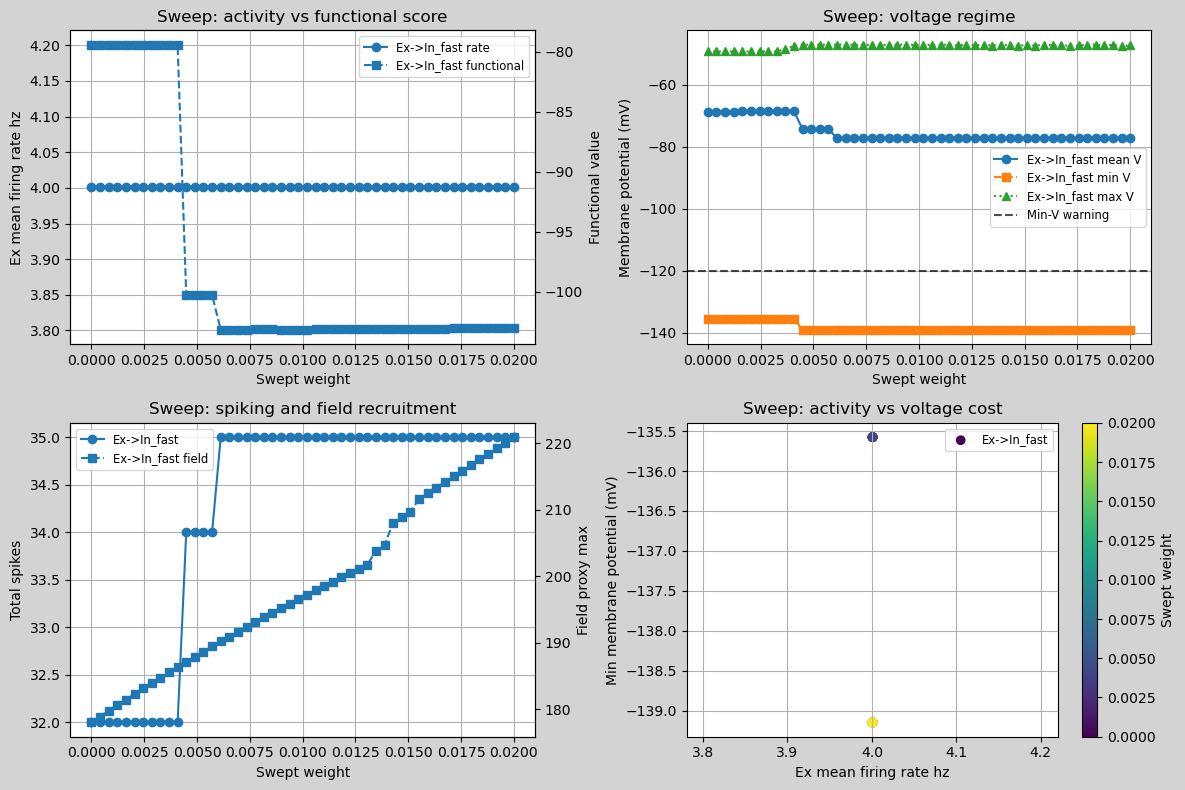

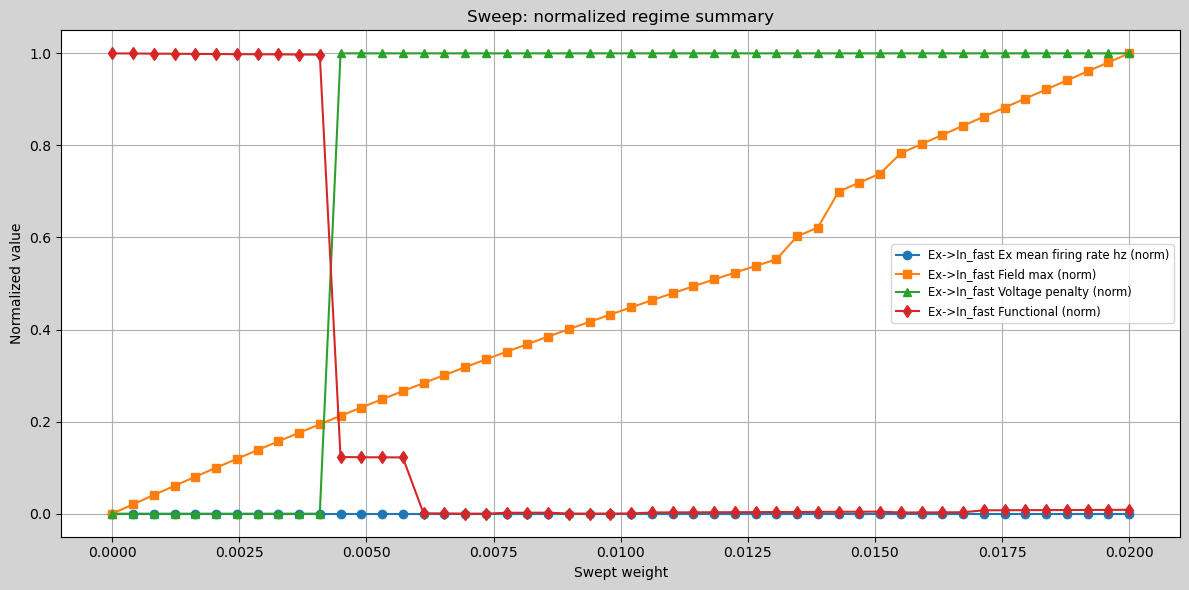

In [165]:
sweep_plot_general(subdf_0006_fast)

sweep_plot_norm_summary(subdf_0006_fast)

In [168]:
subdf = subdf_0006_fast.sort_values("swept_weight").copy()

stable_window = subdf[
    (subdf["In_fast_mean_firing_rate_hz"] < 0.5)
]

transition_window = subdf[
    (subdf["In_fast_mean_firing_rate_hz"] >= 0.5) &
    (subdf["In_fast_mean_firing_rate_hz"] < 1.8)
]

active_plateau_window = subdf[
    (subdf["In_fast_mean_firing_rate_hz"] >= 1.8)
]

print_candidates = False

if print_candidates:
    print("Stable window:")
    print(
        stable_window
        .sort_values("functional_val", ascending=False)
        [["swept_weight", "In_fast_mean_firing_rate_hz", "functional_val"]]
        .head(1)
    )

    print("\n\nTransition window:")
    print(
        transition_window
        .sort_values("functional_val", ascending=False)
        [["swept_weight", "In_fast_mean_firing_rate_hz", "functional_val"]]
        .head(1)
    )

    print("\n\nActive plateau window:")
    print(
        active_plateau_window
        .sort_values("functional_val", ascending=False)
        [["swept_weight", "In_fast_mean_firing_rate_hz", "functional_val"]]
        .head(1)
    )

def representative_row(df, by="swept_weight"):
    if df.empty:
        return df
    center = df[by].median()
    idx = (df[by] - center).abs().idxmin()
    return df.loc[[idx]]

print("Stable window:")
print(representative_row(stable_window)[["swept_weight", "In_fast_mean_firing_rate_hz", "functional_val"]])

print("\n\nTransition window:")
print(representative_row(transition_window)[["swept_weight", "In_fast_mean_firing_rate_hz", "functional_val"]])

print("\n\nActive plateau window:")
print(representative_row(active_plateau_window)[["swept_weight", "In_fast_mean_firing_rate_hz", "functional_val"]])

Stable window:
   swept_weight  In_fast_mean_firing_rate_hz  functional_val
5      0.002041                          0.0      -79.435503


Transition window:
    swept_weight  In_fast_mean_firing_rate_hz  functional_val
13      0.005306                       1.3336     -100.252201


Active plateau window:
    swept_weight  In_fast_mean_firing_rate_hz  functional_val
32      0.013061                       2.0004     -103.075693


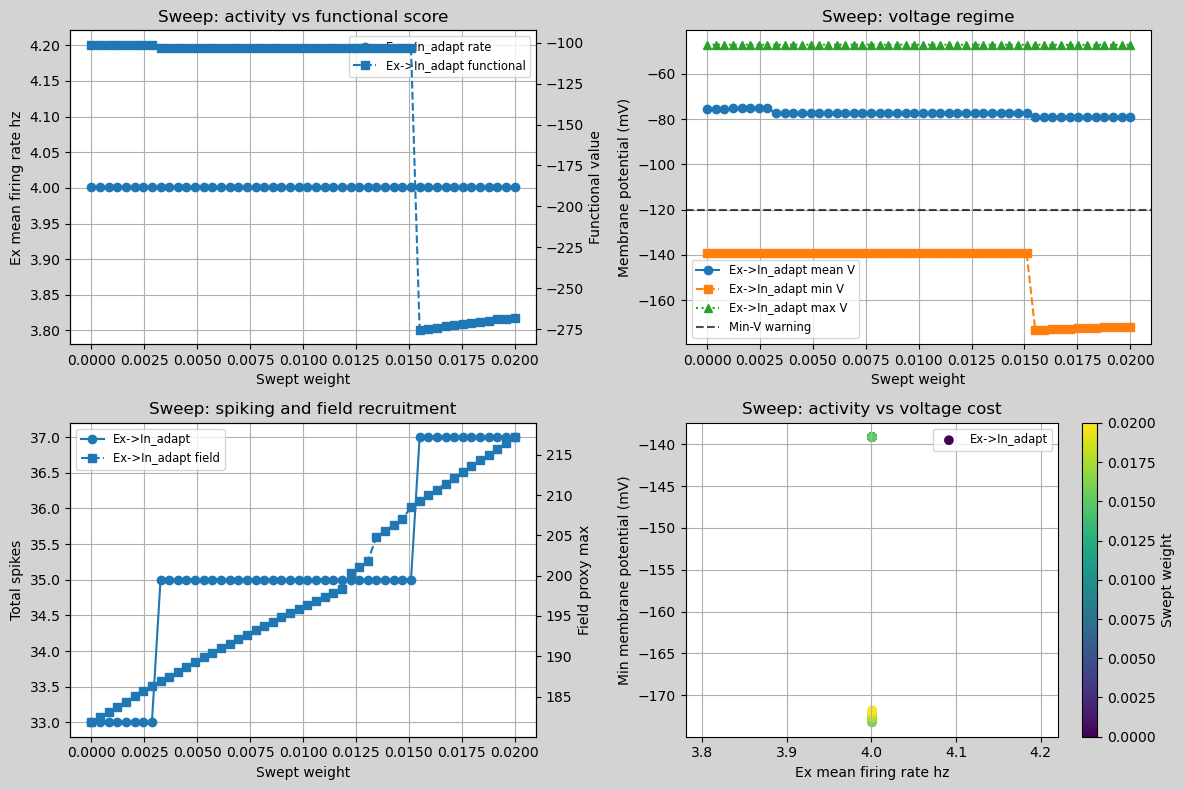

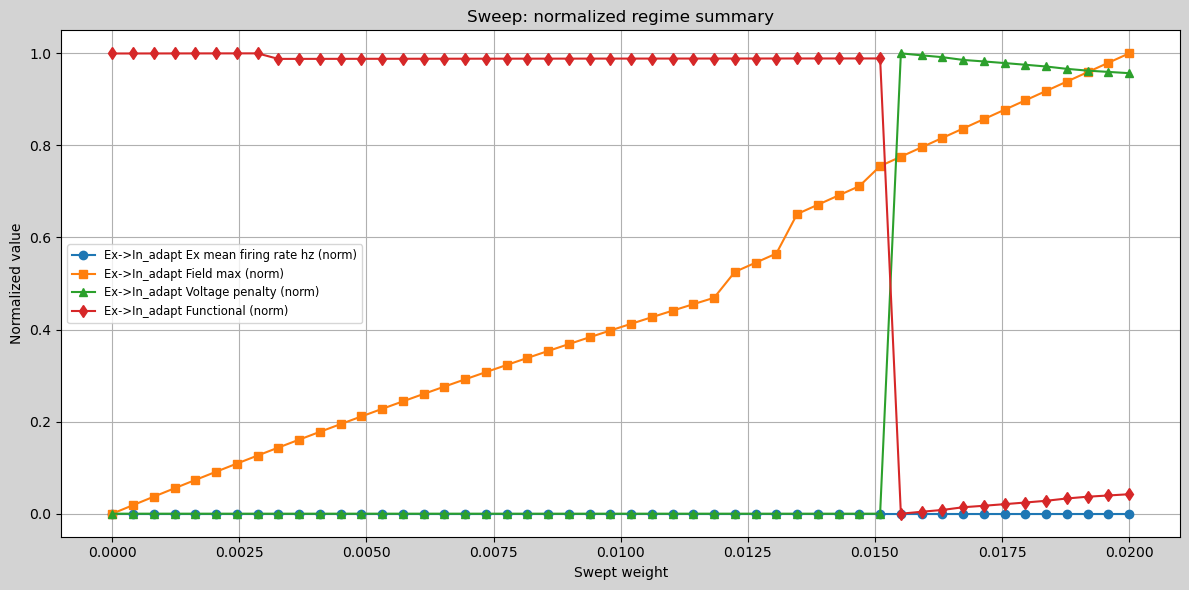

In [169]:
sweep_plot_general(subdf_0006_adapt)

sweep_plot_norm_summary(subdf_0006_adapt)

In [172]:
subdf = subdf_0006_adapt.sort_values("swept_weight").copy()

stable_window = subdf[
    (subdf["In_adapt_mean_firing_rate_hz"] < 0.5)
]

plateau_window = subdf[
    (subdf["In_adapt_mean_firing_rate_hz"] >= 1.8) &
    (subdf["In_adapt_mean_firing_rate_hz"] < 3.0) &
    (subdf["functional_val"] > -150)
]

unstable_window = subdf[
    (subdf["In_adapt_mean_firing_rate_hz"] >= 3.0) |
    (subdf["functional_val"] < -150) |
    (subdf["min_membrane_potential_mv"] < -160)
]

print_candidates = True

if print_candidates:
    print("Stable window:")
    print(
        stable_window
        .sort_values("functional_val", ascending=False)
        [["swept_weight", "In_adapt_mean_firing_rate_hz", "functional_val"]]
        .head(1)
    )

    print("\n\nPlateau window:")
    print(
        plateau_window
        .sort_values("functional_val", ascending=False)
        [["swept_weight", "In_adapt_mean_firing_rate_hz", "functional_val"]]
        .head(1)
    )

    print("\n\nUnstable window:")
    print(
        unstable_window
        .sort_values("functional_val", ascending=False)
        [["swept_weight", "In_adapt_mean_firing_rate_hz", "functional_val"]]
        .head(1)
    )

Stable window:
    swept_weight  In_adapt_mean_firing_rate_hz  functional_val
57      0.002857                           0.0     -101.097659


Plateau window:
    swept_weight  In_adapt_mean_firing_rate_hz  functional_val
87      0.015102                        2.0004     -103.028402


Unstable window:
    swept_weight  In_adapt_mean_firing_rate_hz  functional_val
99          0.02                        4.0008     -268.199083


#### Sweep 0007

Sweep "Ex->In_adapt" in a tighter range to find the behavior transition point.

"Ex->In_adapt" weight (transition) = 0.0153

In [72]:
from neurons_model.simulation.sweep_function import run_sweep

# Define pathways to sweep
SWEEP_PATHWAYS = ("Ex->In_fast",
                  "Ex->In_adapt", 
                  )


# Ex->Ex weight, default is 0.014796
Ex_to_Ex_weights = (0.014796,)

# Sweep Ex->In weights, this includes both Ex->In_fast and Ex->In_adapt. Default for both is 0.008
Ex_to_In_fast_weights = (0.008,)
Ex_to_In_adapt_weights = np.linspace(0.012, 0.018, num=50)


# Define mapping of pathways to their corresponding weight arrays
SWEEP_WEIGHTS = {
    "Ex->Ex": Ex_to_Ex_weights,
    "Ex->In_fast": Ex_to_In_fast_weights,
    "Ex->In_adapt": Ex_to_In_adapt_weights,}

# Commented out to avoid accidental execution, change to True to enable running the sweep again
#run_sweep(sweep_pathways=SWEEP_PATHWAYS, sweep_weights=SWEEP_WEIGHTS, test_number="0007", save=True)

In [ ]:
# Load sweep data
data_path = '/Users/johanrosgaard/Documents/BNQ/neurons_model/tests/sweep_results/sweep_test_0007/sweep_output_data_20260412_164508.npz'
sweep_data = np.load(data_path, allow_pickle=True)

# --- Diagnostic output ---
#diagnostic_mode = True

if diagnostic_mode:
    print("Sweep data keys:", sweep_data.files)
    print("\nSweep data shapes:")
    for key in sweep_data.files:
        print(f"{key} dtype: {sweep_data[key].dtype}, shape: {sweep_data[key].shape}")

sweep_0007_df = pd.DataFrame({k: sweep_data[k] for k in sweep_data.files})

if diagnostic_mode:
    print(sweep_0007_df.head())

# Save to CSV
if saving_mode:
    sweep_0007_df.to_csv("Sweep_csv_files/_sweep_0007_file_output_data_20260412_164508.csv", index=False)

# Print top 10 best and worst performing parameter sets based on functional value
sweep_0007_df.sort_values("functional_val", ascending=False).head(10)
sweep_0007_df.sort_values("functional_val", ascending=True).head(10)

sweep_0007_df.groupby("pathway")[["functional_val", "total_spikes", "field_proxy_max"]].mean()

# Base pathway weights
base_weights = {"Ex->Ex": 0.014796,
                "In_fast->Ex": 0.004,
                "In_adapt->Ex": 0.004}

subdf_0007_adapt = sweep_0007_df[sweep_0007_df["pathway"] == "Ex->In_adapt"].sort_values("swept_weight").copy()

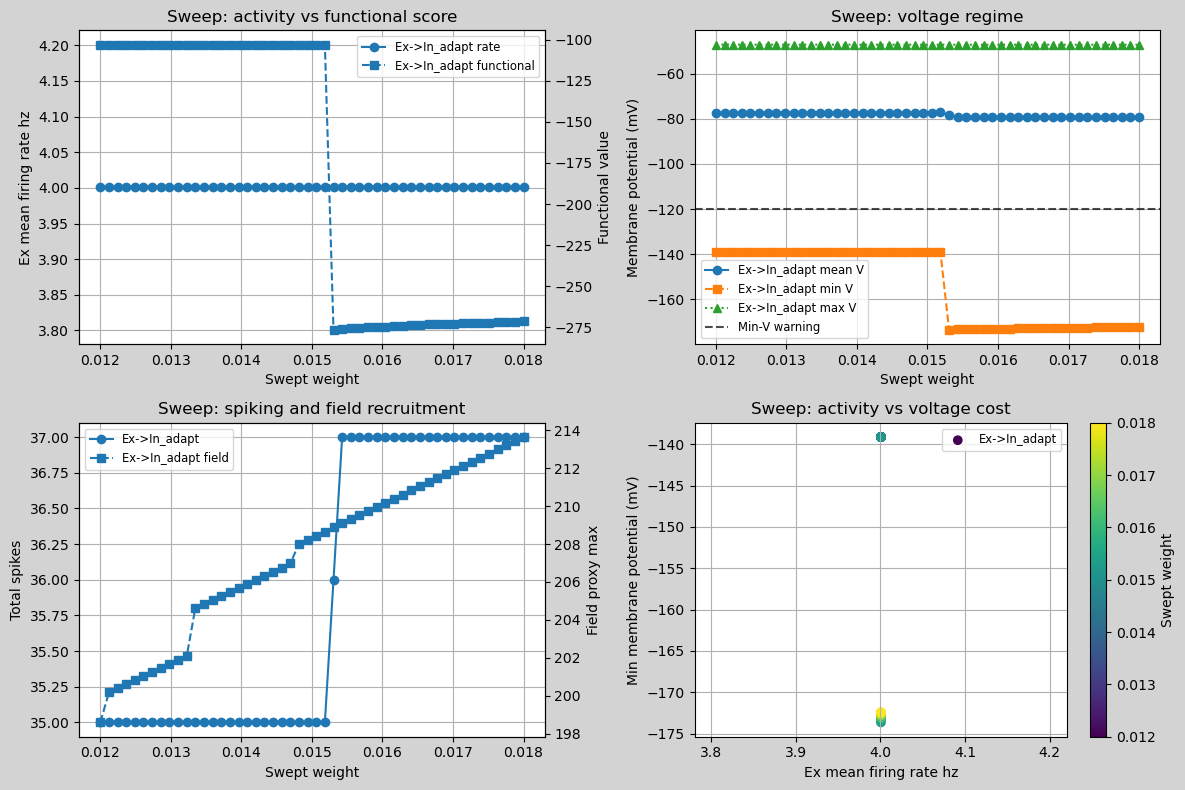

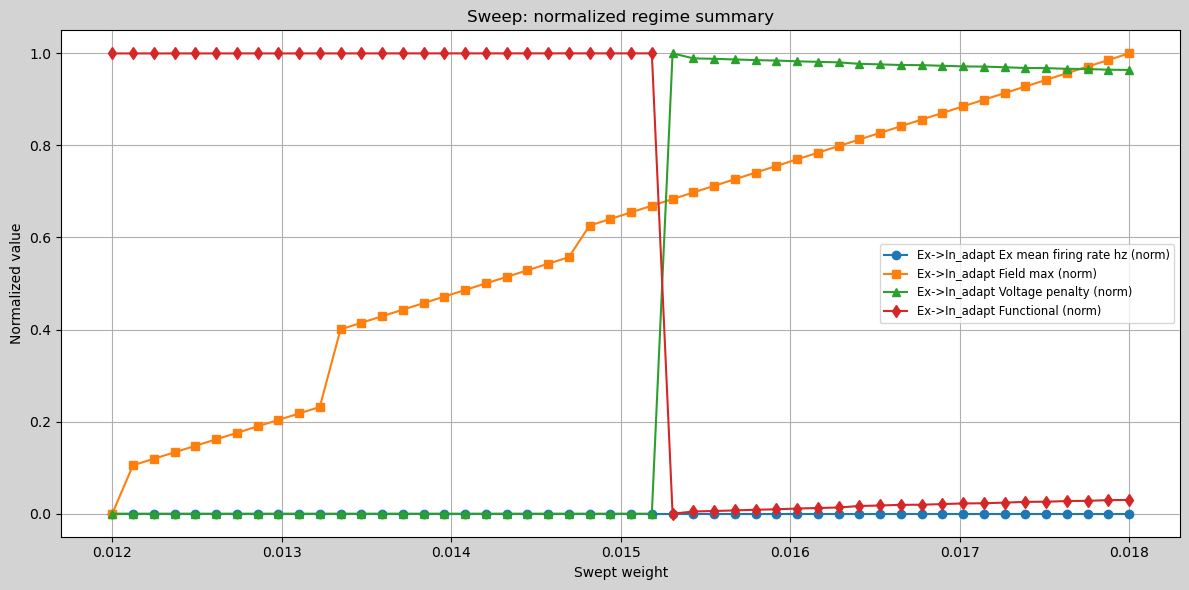

In [174]:
sweep_plot_general(subdf_0007_adapt)

sweep_plot_norm_summary(subdf_0007_adapt)

In [175]:
print("Transition point for Ex->In_adapt sweep:")
print(subdf_0007_adapt[["swept_weight", "Ex_mean_firing_rate_hz", "field_proxy_max", "functional_val"]].sort_values("functional_val", ascending=True).head(1))

Transition point for Ex->In_adapt sweep:
    swept_weight  Ex_mean_firing_rate_hz  field_proxy_max  functional_val
28      0.015306                  4.0008       208.875285     -276.503243


In [76]:
pca_cols = [
    "swept_weight",
    "total_spikes",
    "field_proxy_max",
    "functional_val",
    "mean_membrane_potential_mv",
    "min_membrane_potential_mv",
    "max_membrane_potential_mv",
    "Ex_mean_firing_rate_hz",
    "In_fast_mean_firing_rate_hz",
    "In_adapt_mean_firing_rate_hz",
]

pca_input = subdf_0007_adapt[pca_cols].copy()

# z-score standardization
pca_input_z = (pca_input - pca_input.mean()) / pca_input.std(ddof=0)

projected_df, eigenvalues, eigenvectors, explained_variance_ratio = calvo_pca(
    pca_input_z,
    n_components=10,
)

print(projected_df.head())
print("Explained variance ratio:", explained_variance_ratio[:3])

projected_df["swept_weight"] = subdf_0007_adapt["swept_weight"].values
projected_df["pathway"] = subdf_0007_adapt["pathway"].values



        PC1       PC2       PC3       PC4       PC5       PC6           PC7  \
1  3.792391  1.843110  0.380566  0.105316 -0.012251  0.000255 -2.419695e-07   
2  3.330977  1.095537 -0.124585 -0.064686  0.038030  0.000159 -2.886984e-06   
3  3.290008  1.048181 -0.070143 -0.045505  0.033231  0.000096 -2.389131e-06   
4  3.249036  1.000826 -0.015700 -0.026327  0.028432  0.000038 -1.904157e-06   
5  3.208062  0.953474  0.038744 -0.007151  0.023633 -0.000013 -1.431960e-06   

            PC8  PC9  PC10  
1 -6.025649e-12  0.0   0.0  
2 -7.534209e-11  0.0   0.0  
3 -6.239312e-11  0.0   0.0  
4 -4.977388e-11  0.0   0.0  
5 -3.748149e-11  0.0   0.0  
Explained variance ratio: [0.91049284 0.07953643 0.00680321]


In [77]:
loadings = pd.DataFrame(
    eigenvectors[:, :3],
    index=pca_input_z.columns,
    columns=["PC1", "PC2", "PC3"],
)

print(loadings)

                                   PC1       PC2       PC3
swept_weight                 -0.350898 -0.347332  0.671427
total_spikes                 -0.362193  0.254604  0.074415
field_proxy_max              -0.343835 -0.461783  0.160708
functional_val                0.360935 -0.259368  0.221568
mean_membrane_potential_mv    0.361536 -0.264864 -0.065083
min_membrane_potential_mv     0.360881 -0.259270  0.225004
max_membrane_potential_mv     0.324133  0.576043  0.639006
Ex_mean_firing_rate_hz        0.000000  0.000000  0.000000
In_fast_mean_firing_rate_hz   0.000000  0.000000  0.000000
In_adapt_mean_firing_rate_hz -0.362193  0.254604  0.074415


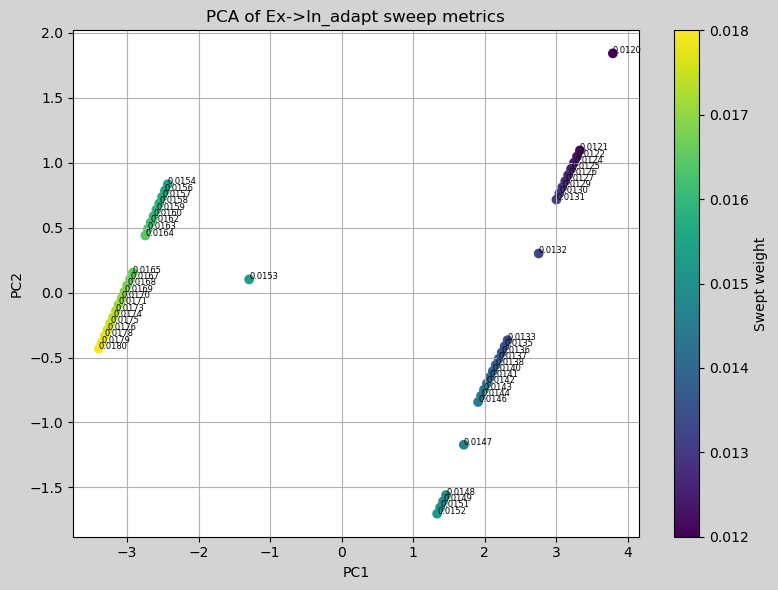

In [78]:
plt.figure(figsize=(8, 6))

sc = plt.scatter(projected_df["PC1"], projected_df["PC2"], c=projected_df["swept_weight"], cmap="viridis")
for _, row in projected_df.iterrows():
    plt.annotate(f"{row['swept_weight']:.4f}", (row["PC1"], row["PC2"]), fontsize=6)

plt.colorbar(sc, label="Swept weight")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Ex->In_adapt sweep metrics")
plt.grid()
plt.tight_layout()
plt.show()